In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [92]:
# Load the dataset
df = pd.read_csv(r'D:\\elevateLabs\dataAnalytics\\project2\WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Employees: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

DATASET OVERVIEW

Dataset Shape: (1470, 35)
Total Employees: 1470
Total Features: 35


In [93]:
# Display first few rows
print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

# Dataset info
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())

# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe())


FIRST 5 ROWS
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

In [94]:
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Check unique values for potential constant columns
print("\nChecking for constant columns:")
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count == 1:
        print(f"  - {col}: {unique_count} unique value(s) -> {df[col].unique()}")

# Remove constant/unnecessary columns
columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop)
    print(f"\nDropped columns: {existing_cols_to_drop}")

print(f"\nCleaned Dataset Shape: {df.shape}")


DATA CLEANING

Missing Values:
No missing values found!

Duplicate Rows: 0

Checking for constant columns:
  - EmployeeCount: 1 unique value(s) -> [1]
  - Over18: 1 unique value(s) -> ['Y']
  - StandardHours: 1 unique value(s) -> [80]

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours']

Cleaned Dataset Shape: (1470, 32)



EXPLORATORY DATA ANALYSIS

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


<Figure size 1200x800 with 0 Axes>

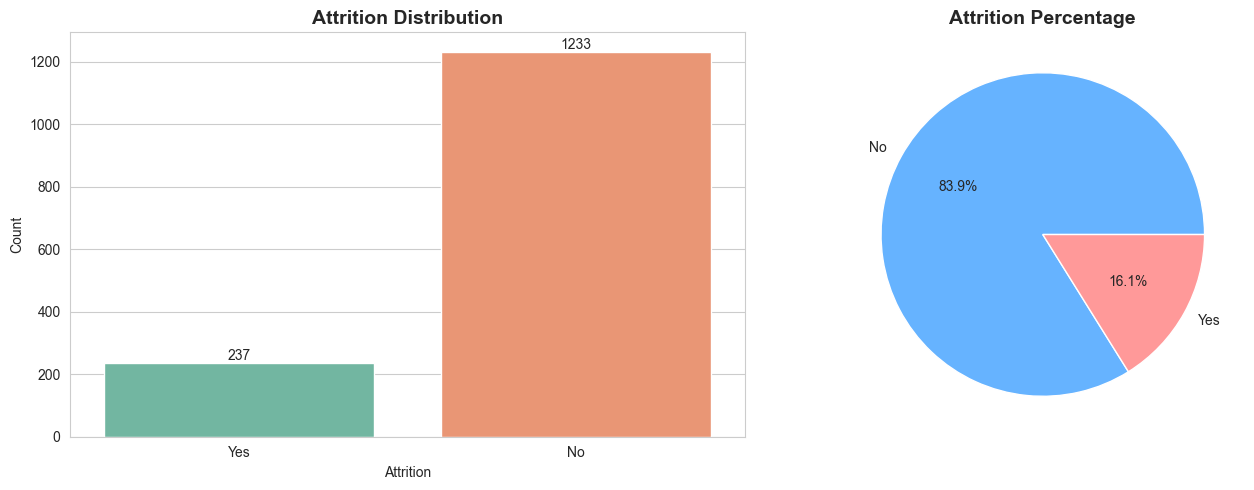

In [95]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Target variable distribution
print("\nAttrition Distribution:")
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nAttrition Rate: {(attrition_counts['Yes'] / len(df) * 100):.2f}%")

# Visualization: Overall Attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(data=df, x='Attrition', palette='Set2', ax=axes[0])
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
attrition_counts.plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], ax=axes[1])
axes[1].set_title('Attrition Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


DEPARTMENT-WISE ATTRITION ANALYSIS

Department vs Attrition (Count):
Attrition                 No  Yes   All
Department                             
Human Resources           51   12    63
Research & Development   828  133   961
Sales                    354   92   446
All                     1233  237  1470

Department vs Attrition (Percentage):
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


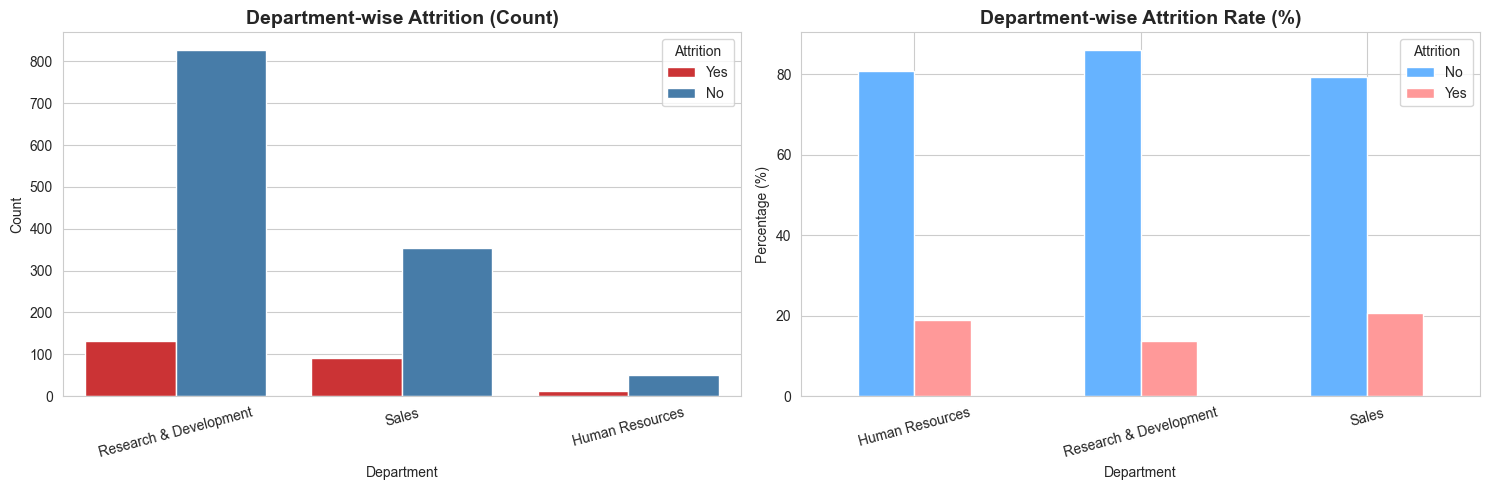

In [96]:
print("\n" + "=" * 60)
print("DEPARTMENT-WISE ATTRITION ANALYSIS")
print("=" * 60)

dept_attrition = pd.crosstab(df['Department'], df['Attrition'], margins=True)
print("\nDepartment vs Attrition (Count):")
print(dept_attrition)

dept_attrition_pct = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
print("\nDepartment vs Attrition (Percentage):")
print(dept_attrition_pct.round(2))

# Visualization: Department-wise Attrition
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Countplot
dept_order = df['Department'].value_counts().index
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set1', order=dept_order, ax=axes[0])
axes[0].set_title('Department-wise Attrition (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')
axes[0].legend(title='Attrition')
axes[0].tick_params(axis='x', rotation=15)

# Percentage plot
dept_attrition_pct.plot(kind='bar', stacked=False, color=['#66b3ff','#ff9999'], ax=axes[1])
axes[1].set_title('Department-wise Attrition Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Attrition')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


SALARY BANDS ANALYSIS

Salary Band Distribution:
SalaryBand
Low (0-3K)          395
Medium (3-6K)       519
High (6-10K)        275
Very High (10K+)    281
Name: count, dtype: int64

Salary Band vs Attrition (Count):
Attrition           No  Yes   All
SalaryBand                       
Low (0-3K)         282  113   395
Medium (3-6K)      453   66   519
High (6-10K)       242   33   275
Very High (10K+)   256   25   281
All               1233  237  1470

Salary Band vs Attrition (Percentage):
Attrition            No    Yes
SalaryBand                    
Low (0-3K)        71.39  28.61
Medium (3-6K)     87.28  12.72
High (6-10K)      88.00  12.00
Very High (10K+)  91.10   8.90


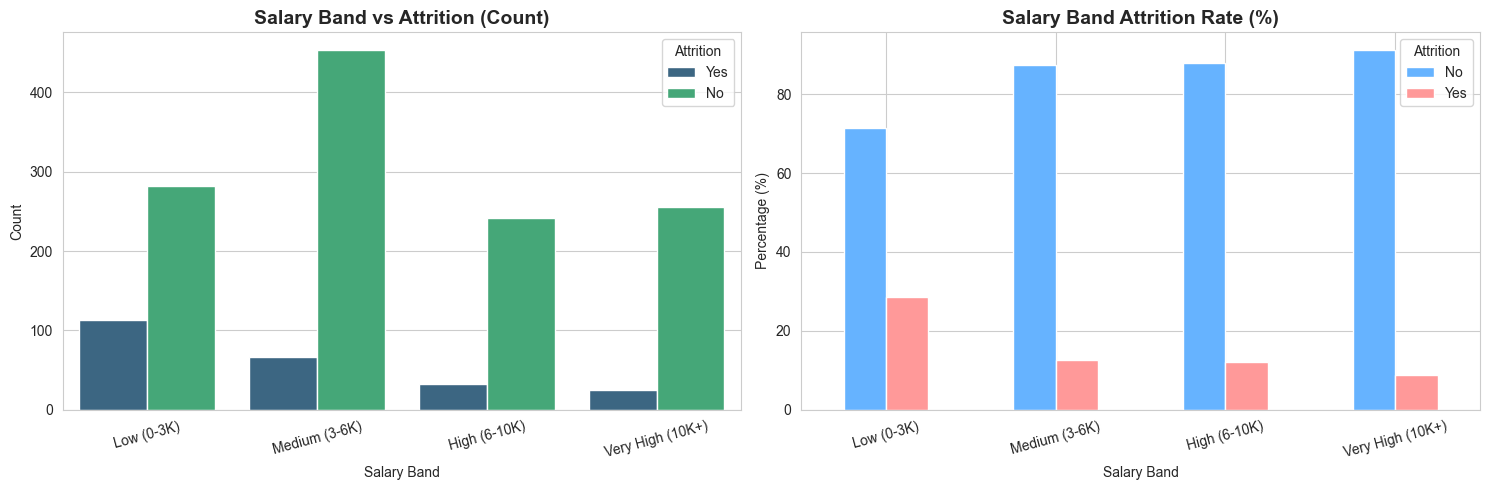

In [97]:
print("\n" + "=" * 60)
print("SALARY BANDS ANALYSIS")
print("=" * 60)

# Create salary bands
df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'], 
    bins=[0, 3000, 6000, 10000, 20000], 
    labels=['Low (0-3K)', 'Medium (3-6K)', 'High (6-10K)', 'Very High (10K+)']
)

print("\nSalary Band Distribution:")
print(df['SalaryBand'].value_counts().sort_index())

salary_attrition = pd.crosstab(df['SalaryBand'], df['Attrition'], margins=True)
print("\nSalary Band vs Attrition (Count):")
print(salary_attrition)

salary_attrition_pct = pd.crosstab(df['SalaryBand'], df['Attrition'], normalize='index') * 100
print("\nSalary Band vs Attrition (Percentage):")
print(salary_attrition_pct.round(2))

# Visualization: Salary Bands
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Countplot
sns.countplot(data=df, x='SalaryBand', hue='Attrition', palette='viridis', ax=axes[0])
axes[0].set_title('Salary Band vs Attrition (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary Band')
axes[0].set_ylabel('Count')
axes[0].legend(title='Attrition')
axes[0].tick_params(axis='x', rotation=15)

# Percentage plot
salary_attrition_pct.plot(kind='bar', stacked=False, color=['#66b3ff','#ff9999'], ax=axes[1])
axes[1].set_title('Salary Band Attrition Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salary Band')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Attrition')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

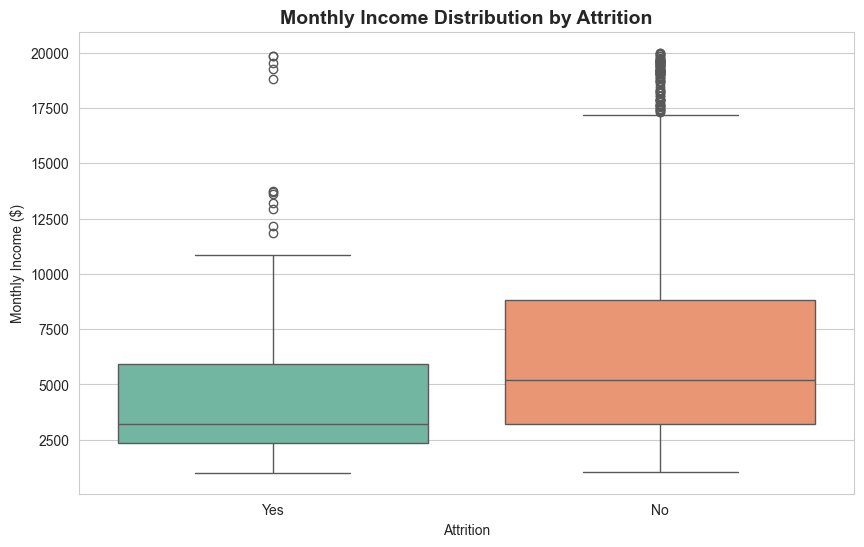

In [98]:
# Box plot: Monthly Income vs Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income Distribution by Attrition', fontsize=14, fontweight='bold')
plt.ylabel('Monthly Income ($)')
plt.show()


------------------------------------------------------------
PROMOTIONS ANALYSIS
------------------------------------------------------------

Years Since Last Promotion - Summary:

            count      mean       std  min  25%  50%  75%   max
Attrition                                                      
No         1233.0  2.234388  3.234762  0.0  0.0  1.0  3.0  15.0
Yes         237.0  1.945148  3.153077  0.0  0.0  1.0  2.0  15.0


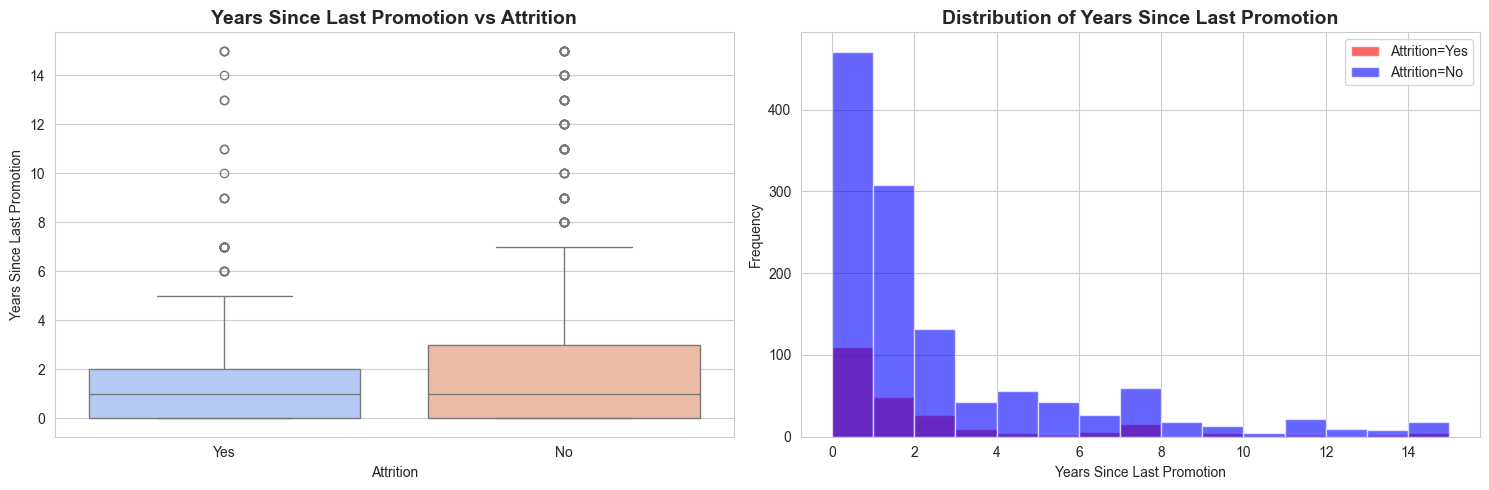

In [99]:
print("\n" + "-" * 60)
print("PROMOTIONS ANALYSIS")
print("-" * 60)

print("\nYears Since Last Promotion - Summary:\n")
print(df.groupby('Attrition')['YearsSinceLastPromotion'].describe())

# Visualization: Promotions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', palette='coolwarm', ax=axes[0])
axes[0].set_title('Years Since Last Promotion vs Attrition', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Years Since Last Promotion')

# Histogram
df[df['Attrition']=='Yes']['YearsSinceLastPromotion'].hist(alpha=0.6, bins=15, label='Attrition=Yes', color='red', ax=axes[1])
df[df['Attrition']=='No']['YearsSinceLastPromotion'].hist(alpha=0.6, bins=15, label='Attrition=No', color='blue', ax=axes[1])
axes[1].set_title('Distribution of Years Since Last Promotion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Years Since Last Promotion')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()


Promotion Recency vs Attrition Rate (%):
Attrition            No    Yes
PromotionRecency              
Recent (0y)       81.07  18.93
Moderate (1-2y)   85.27  14.73
Long (3-5y)       89.87  10.13
Very Long (5y+)   83.72  16.28


<Figure size 1000x600 with 0 Axes>

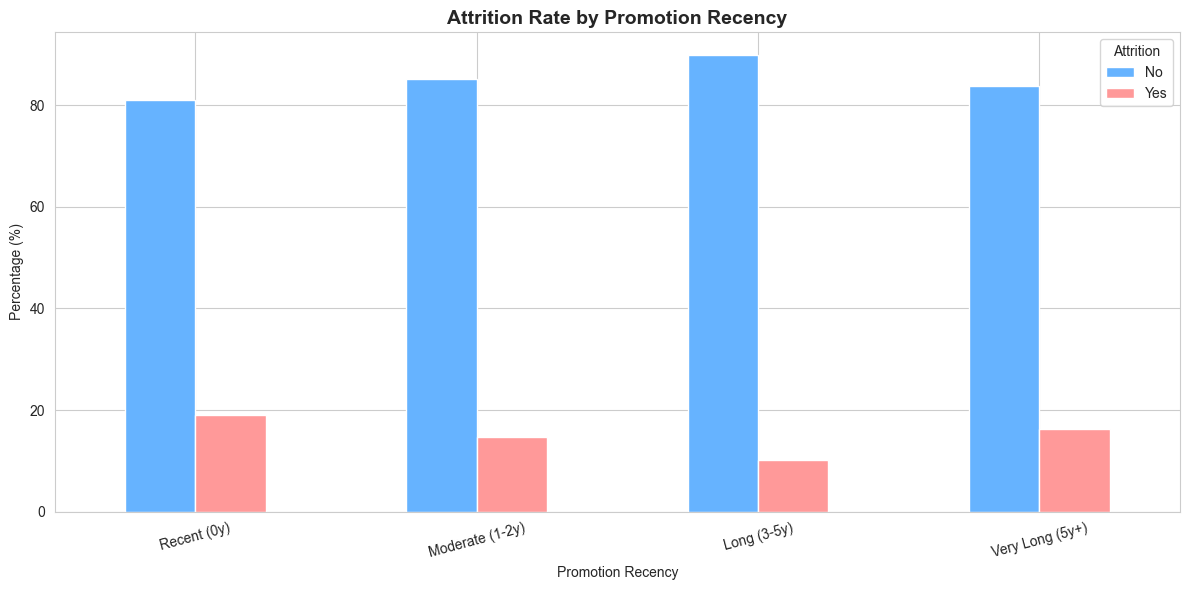

In [100]:
# Create promotion recency categories
df['PromotionRecency'] = pd.cut(
    df['YearsSinceLastPromotion'], 
    bins=[-1, 0, 2, 5, 100], 
    labels=['Recent (0y)', 'Moderate (1-2y)', 'Long (3-5y)', 'Very Long (5y+)']
)

promotion_attrition = pd.crosstab(df['PromotionRecency'], df['Attrition'], normalize='index') * 100
print("\nPromotion Recency vs Attrition Rate (%):")
print(promotion_attrition.round(2))

plt.figure(figsize=(10, 6))
promotion_attrition.plot(kind='bar', stacked=False, color=['#66b3ff','#ff9999'])
plt.title('Attrition Rate by Promotion Recency', fontsize=14, fontweight='bold')
plt.xlabel('Promotion Recency')
plt.ylabel('Percentage (%)')
plt.legend(title='Attrition')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


------------------------------------------------------------
ADDITIONAL INSIGHTS
------------------------------------------------------------

Age Distribution by Attrition:

            count       mean      std   min   25%   50%   75%   max
Attrition                                                          
No         1233.0  37.561233  8.88836  18.0  31.0  36.0  43.0  60.0
Yes         237.0  33.607595  9.68935  18.0  28.0  32.0  39.0  58.0

OverTime vs Attrition Rate (%):
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53

Top 5 Job Roles with Highest Attrition Rate:
JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Yes, dtype: float64


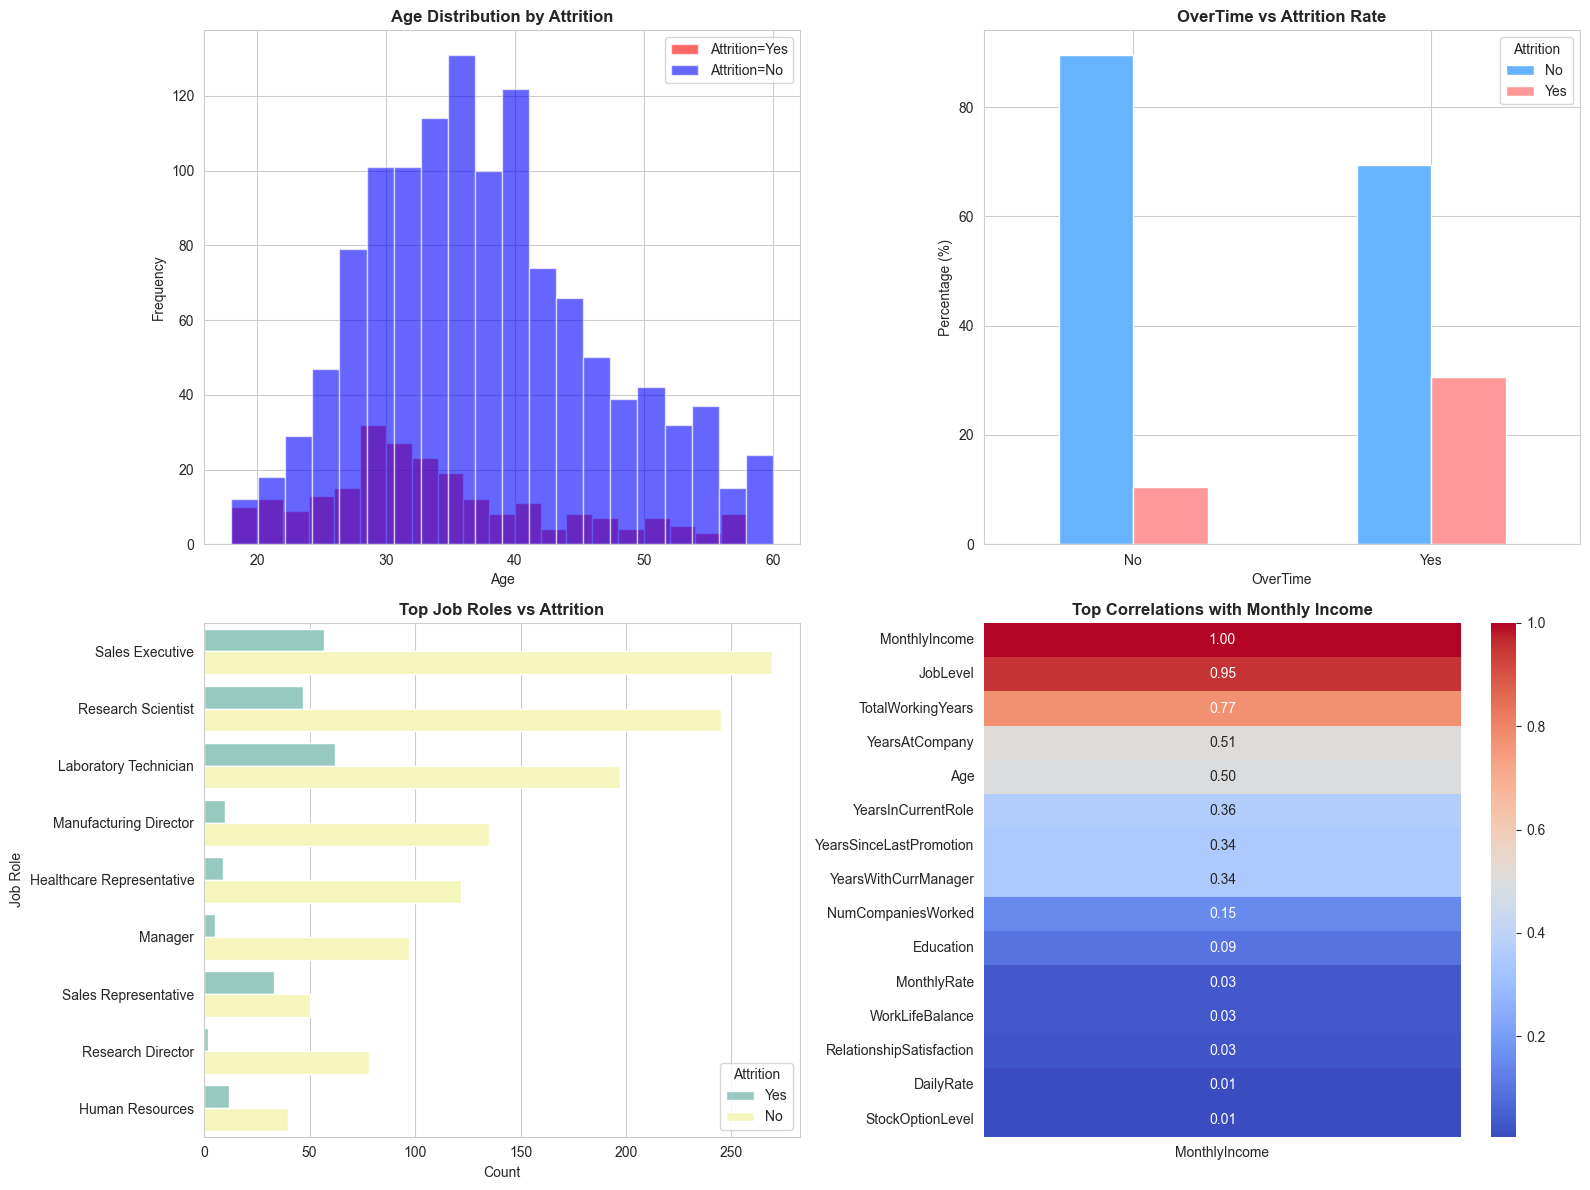

In [101]:
print("\n" + "-" * 60)
print("ADDITIONAL INSIGHTS")
print("-" * 60)

# Age distribution
print("\nAge Distribution by Attrition:\n")
print(df.groupby('Attrition')['Age'].describe())

# OverTime analysis
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
print("\nOverTime vs Attrition Rate (%):")
print(overtime_attrition.round(2))

# Job Role analysis
jobrole_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
print("\nTop 5 Job Roles with Highest Attrition Rate:")
print(jobrole_attrition['Yes'].sort_values(ascending=False).head())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution
df[df['Attrition']=='Yes']['Age'].hist(alpha=0.6, bins=20, label='Attrition=Yes', color='red', ax=axes[0,0])
df[df['Attrition']=='No']['Age'].hist(alpha=0.6, bins=20, label='Attrition=No', color='blue', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# OverTime
overtime_attrition.plot(kind='bar', stacked=False, color=['#66b3ff','#ff9999'], ax=axes[0,1])
axes[0,1].set_title('OverTime vs Attrition Rate', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('OverTime')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(title='Attrition')
axes[0,1].tick_params(axis='x', rotation=0)

# Job Role (top 10)
top_roles = df['JobRole'].value_counts().head(10).index
jobrole_data = df[df['JobRole'].isin(top_roles)]
sns.countplot(data=jobrole_data, y='JobRole', hue='Attrition', palette='Set3', 
              order=jobrole_data['JobRole'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title('Top Job Roles vs Attrition', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Count')
axes[1,0].set_ylabel('Job Role')

# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
top_corr_features = corr_matrix.index
sns.heatmap(corr_matrix[['MonthlyIncome']].sort_values(by='MonthlyIncome', ascending=False).head(15), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Top Correlations with Monthly Income', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [102]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING & PREPROCESSING")
print("=" * 60)

# Create a copy for modeling
df_model = df.copy()

# Drop EmployeeNumber (ID column) and derived features created during EDA
# SalaryBand and PromotionRecency were created for EDA visualization only
columns_to_drop_modeling = ['EmployeeNumber', 'SalaryBand', 'PromotionRecency']
df_model = df_model.drop(columns=columns_to_drop_modeling, errors='ignore')
print(f"\nDropped columns for modeling: {[col for col in columns_to_drop_modeling if col in df.columns]}")

# Encode target variable
label_encoder_target = LabelEncoder()
df_model['Attrition'] = label_encoder_target.fit_transform(df_model['Attrition'])
print(f"\nTarget encoding: {dict(zip(label_encoder_target.classes_, label_encoder_target.transform(label_encoder_target.classes_)))}")

# Identify categorical columns
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

print(f"\nDataset shape after encoding: {df_model.shape}")
print("\nFirst few rows after encoding:")
print(df_model.head())

# Separate features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")



FEATURE ENGINEERING & PREPROCESSING

Dropped columns for modeling: ['EmployeeNumber', 'SalaryBand', 'PromotionRecency']

Target encoding: {'No': np.int64(0), 'Yes': np.int64(1)}

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Dataset shape after encoding: (1470, 31)

First few rows after encoding:
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1    

In [103]:
print("\n" + "-" * 60)
print("LOGISTIC REGRESSION MODEL")
print("-" * 60)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("\nLogistic Regression - Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Attrition', 'Attrition']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores: {cv_scores_lr}")
print(f"Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")


------------------------------------------------------------
LOGISTIC REGRESSION MODEL
------------------------------------------------------------

Logistic Regression - Performance Metrics:
Accuracy: 0.8741
ROC-AUC Score: 0.8057

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      0.97      0.93       247
   Attrition       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294


Confusion Matrix:
[[239   8]
 [ 29  18]]

Cross-Validation Scores: [0.85169492 0.87234043 0.87659574 0.86382979 0.88085106]
Mean CV Accuracy: 0.8691 (+/- 0.0207)


In [104]:
print("\n" + "-" * 60)
print("DECISION TREE CLASSIFIER")
print("-" * 60)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20, min_samples_leaf=10)
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("\nDecision Tree - Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Attrition', 'Attrition']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(cm_dt)

# Cross-validation
cv_scores_dt = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores: {cv_scores_dt}")
print(f"Mean CV Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std() * 2:.4f})")


------------------------------------------------------------
DECISION TREE CLASSIFIER
------------------------------------------------------------

Decision Tree - Performance Metrics:
Accuracy: 0.8401
ROC-AUC Score: 0.6941

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.87      0.95      0.91       247
   Attrition       0.50      0.28      0.36        47

    accuracy                           0.84       294
   macro avg       0.69      0.61      0.63       294
weighted avg       0.81      0.84      0.82       294


Confusion Matrix:
[[234  13]
 [ 34  13]]

Cross-Validation Scores: [0.80932203 0.79574468 0.84680851 0.83829787 0.80851064]
Mean CV Accuracy: 0.8197 (+/- 0.0389)



MODEL COMPARISON

               Model  Accuracy  ROC-AUC  CV Mean Accuracy
Logistic Regression  0.874150 0.805668          0.869062
      Decision Tree  0.840136 0.694117          0.819737


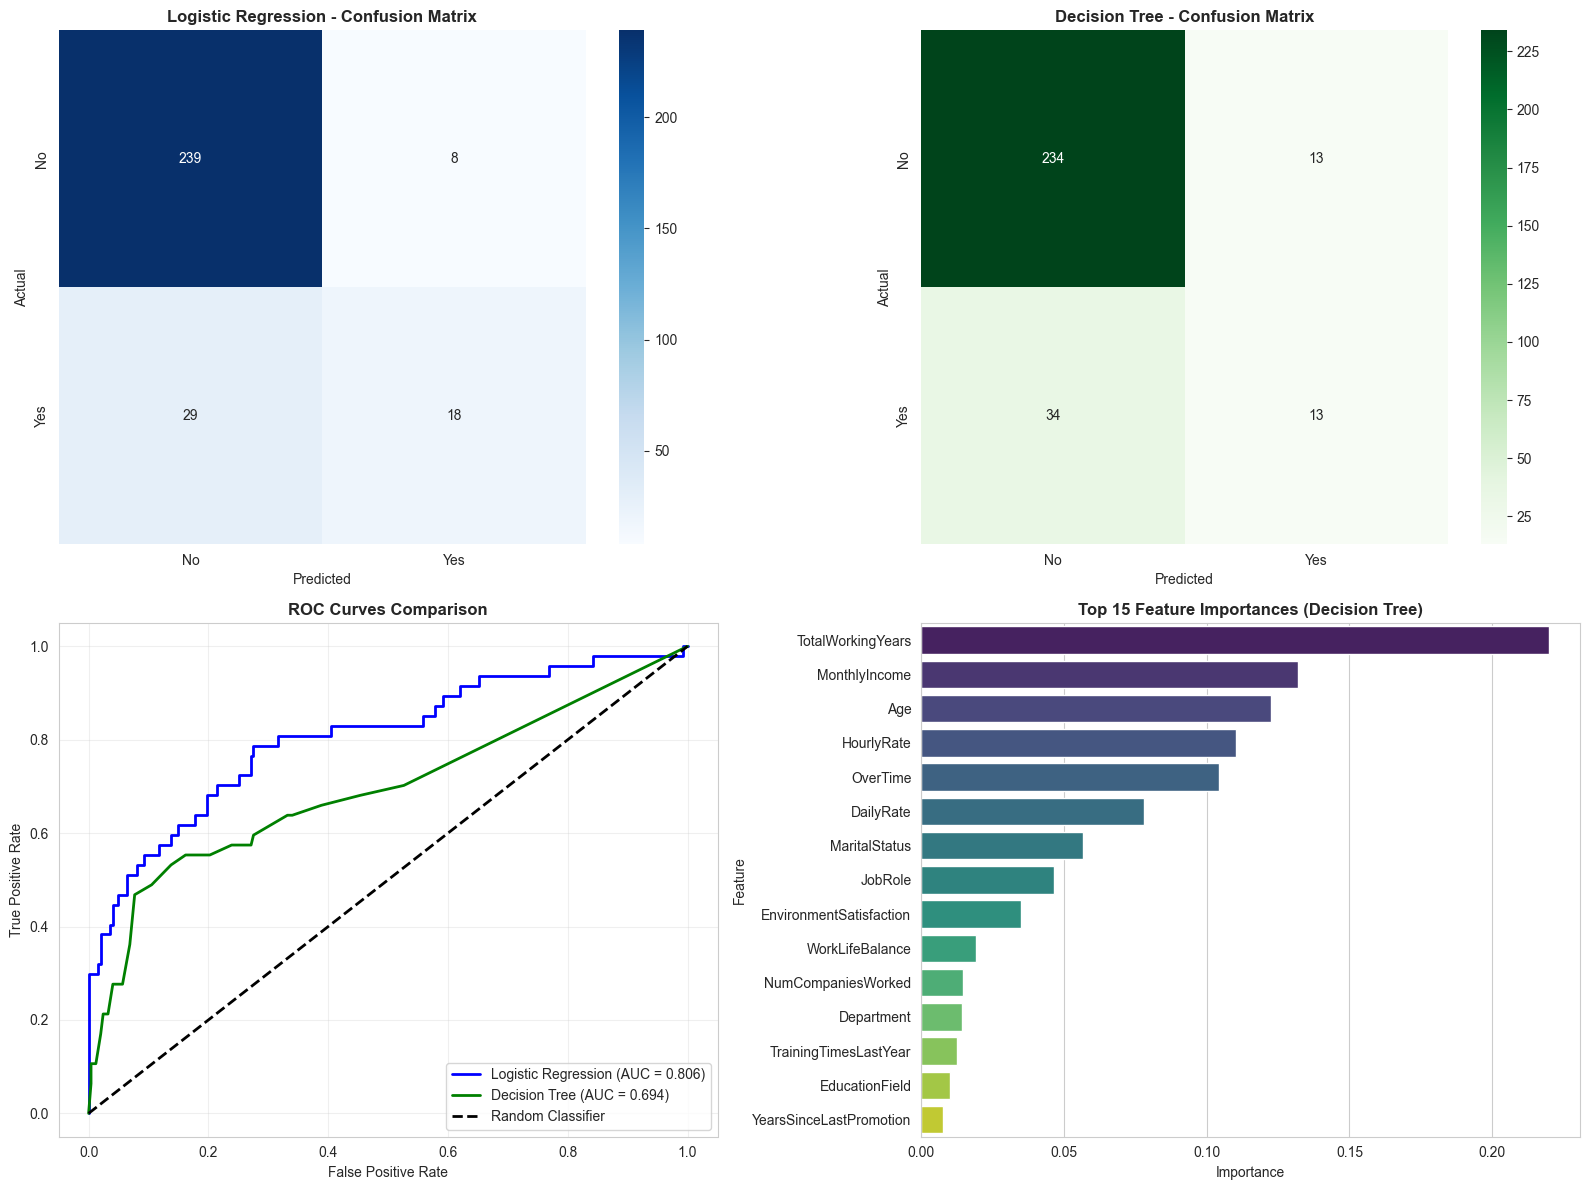

In [105]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_dt)
    ],
    'CV Mean Accuracy': [
        cv_scores_lr.mean(),
        cv_scores_dt.mean()
    ]
})

print("\n", comparison_df.to_string(index=False))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrices
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0,0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0,1], 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0,1].set_title('Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Actual')
axes[0,1].set_xlabel('Predicted')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

axes[1,0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f})', color='blue', lw=2)
axes[1,0].plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_pred_proba_dt):.3f})', color='green', lw=2)
axes[1,0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
axes[1,0].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend(loc='lower right')
axes[1,0].grid(True, alpha=0.3)

# Feature Importance (Decision Tree)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

sns.barplot(data=feature_importance, y='Feature', x='Importance', palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Top 15 Feature Importances (Decision Tree)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

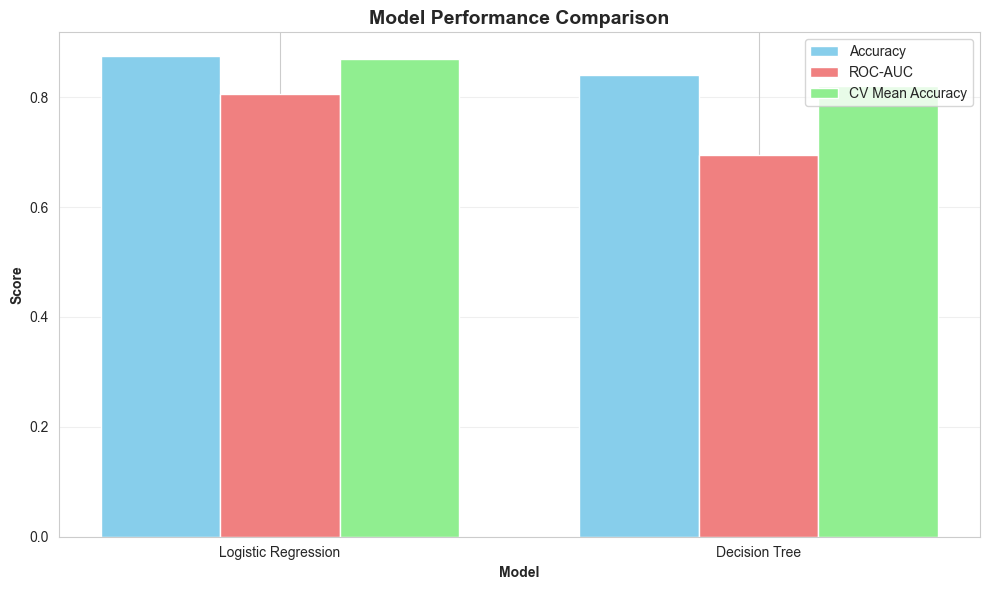

In [106]:
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison_df))
width = 0.25

ax.bar(x_pos - width, comparison_df['Accuracy'], width, label='Accuracy', color='skyblue')
ax.bar(x_pos, comparison_df['ROC-AUC'], width, label='ROC-AUC', color='lightcoral')
ax.bar(x_pos + width, comparison_df['CV Mean Accuracy'], width, label='CV Mean Accuracy', color='lightgreen')

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [107]:
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

print(f"""
KEY FINDINGS:

1. Dataset Overview:
   - Total Employees: {df.shape[0]}
   - Overall Attrition Rate: {(attrition_counts['Yes'] / len(df) * 100):.2f}%

2. Department-wise Attrition:
{dept_attrition_pct.to_string()}

3. Salary Impact:
   - Employees in lower salary bands show higher attrition rates
   
4. Promotions:
   - Longer time since promotion correlates with higher attrition

5. Model Performance:
   - Best Model: {comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']}
   - Best ROC-AUC: {comparison_df['ROC-AUC'].max():.4f}
   - Best Accuracy: {comparison_df['Accuracy'].max():.4f}

RECOMMENDATIONS:
- Focus retention efforts on departments with high attrition
- Review compensation for lower salary bands
- Implement regular promotion cycles
- Consider OverTime policies
- Target high-risk job roles identified in analysis
""")


ANALYSIS SUMMARY

KEY FINDINGS:

1. Dataset Overview:
   - Total Employees: 1470
   - Overall Attrition Rate: 16.12%

2. Department-wise Attrition:
Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803

3. Salary Impact:
   - Employees in lower salary bands show higher attrition rates

4. Promotions:
   - Longer time since promotion correlates with higher attrition

5. Model Performance:
   - Best Model: Logistic Regression
   - Best ROC-AUC: 0.8057
   - Best Accuracy: 0.8741

RECOMMENDATIONS:
- Focus retention efforts on departments with high attrition
- Review compensation for lower salary bands
- Implement regular promotion cycles
- Consider OverTime policies
- Target high-risk job roles identified in analysis



In [122]:
import sys
import subprocess

# Check if SHAP is installed
try:
    import shap
    print("\n✅ SHAP library is already installed!")
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("\n⚙️  Installing SHAP library...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"✅ SHAP installed successfully! Version: {shap.__version__}")


✅ SHAP library is already installed!
SHAP version: 0.49.1


In [124]:
print("\n" + "-" * 70)
print("VERIFYING REQUIRED VARIABLES")
print("-" * 70)

required_vars = ['lr_model', 'dt_model', 'X_train_scaled', 'X_test_scaled', 
                 'y_train', 'y_test', 'y_pred_lr', 'y_pred_dt', 'X']

missing = []
for var in required_vars:
    if var not in globals():
        missing.append(var)

if missing:
    print(f"\n❌ ERROR: Missing required variables: {missing}")
    print("\n🔧 Please run the following sections first:")
    print("   1. Data Loading & Cleaning")
    print("   2. Feature Engineering & Preprocessing")
    print("   3. Model Training (Logistic Regression)")
    print("   4. Model Training (Decision Tree)")
    raise NameError(f"Required variables not found: {missing}")
else:
    print("\nAll required variables are available!")
    print(f"   - Models: lr_model, dt_model")
    print(f"   - Data: X_train_scaled ({X_train_scaled.shape}), X_test_scaled ({X_test_scaled.shape})")
    print(f"   - Target: y_train ({y_train.shape}), y_test ({y_test.shape})")
    print(f"   - Features: X ({X.shape[1]} features)")

# Convert feature names to list for SHAP
feature_names_list = X.columns.tolist()
print(f"\n Feature names: {len(feature_names_list)} features converted to list")




----------------------------------------------------------------------
VERIFYING REQUIRED VARIABLES
----------------------------------------------------------------------

All required variables are available!
   - Models: lr_model, dt_model
   - Data: X_train_scaled ((1176, 30)), X_test_scaled ((294, 30))
   - Target: y_train ((1176,)), y_test ((294,))
   - Features: X (30 features)

 Feature names: 30 features converted to list


In [125]:
print("\n" + "=" * 70)
print("SHAP ANALYSIS - LOGISTIC REGRESSION")
print("=" * 70)

# Create SHAP explainer for Logistic Regression
print("\nCreating LinearExplainer for Logistic Regression...")
explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled)

# Calculate SHAP values for test set
print("Calculating SHAP values...")
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values_lr.shape}")

# Global feature importance (mean absolute SHAP values)
feature_importance_shap_lr = pd.DataFrame({
    'Feature': feature_names_list,
    'SHAP_Importance': np.abs(shap_values_lr).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 15 Most Important Features (Logistic Regression - SHAP):")
print(feature_importance_shap_lr.head(15).to_string(index=False))



SHAP ANALYSIS - LOGISTIC REGRESSION

Creating LinearExplainer for Logistic Regression...
Calculating SHAP values...
SHAP values shape: (294, 30)

Top 15 Most Important Features (Logistic Regression - SHAP):
                Feature  SHAP_Importance
               OverTime         0.695803
EnvironmentSatisfaction         0.394304
             Department         0.393615
   YearsWithCurrManager         0.388884
     NumCompaniesWorked         0.381452
YearsSinceLastPromotion         0.379454
        JobSatisfaction         0.346505
      TotalWorkingYears         0.342715
     YearsInCurrentRole         0.332618
                    Age         0.330296
         JobInvolvement         0.306009
       DistanceFromHome         0.249515
          MaritalStatus         0.245526
       StockOptionLevel         0.236463
                JobRole         0.235732



Generating Summary Plot - Logistic Regression...


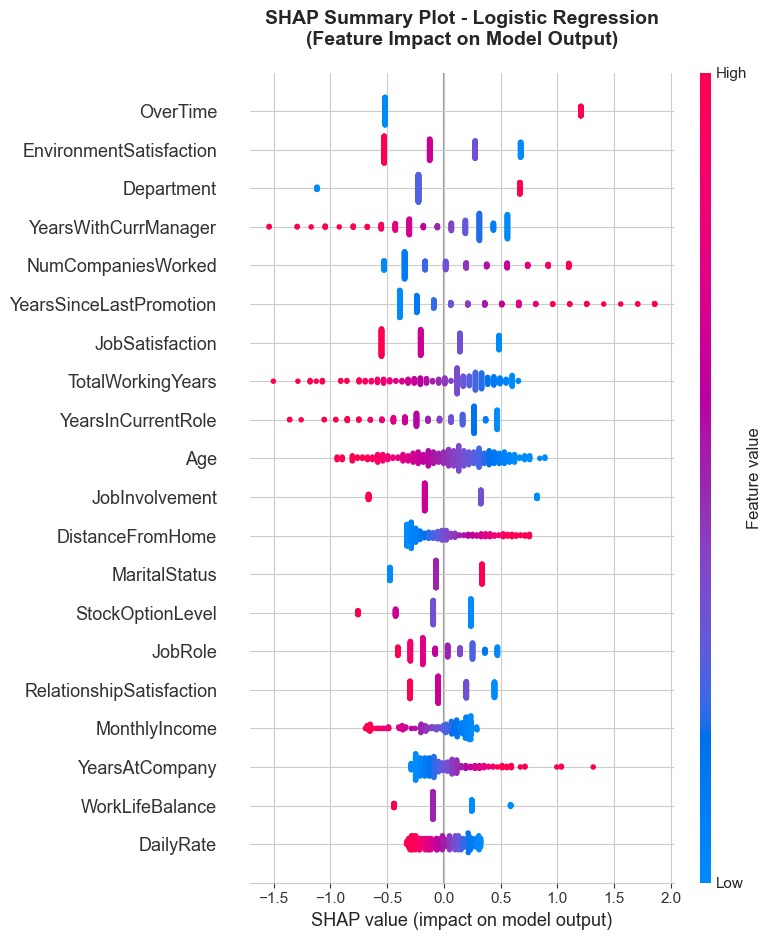

In [126]:
print("\nGenerating Summary Plot - Logistic Regression...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=feature_names_list, show=False)
plt.title('SHAP Summary Plot - Logistic Regression\n(Feature Impact on Model Output)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Generating Feature Importance Bar Plot - Logistic Regression...


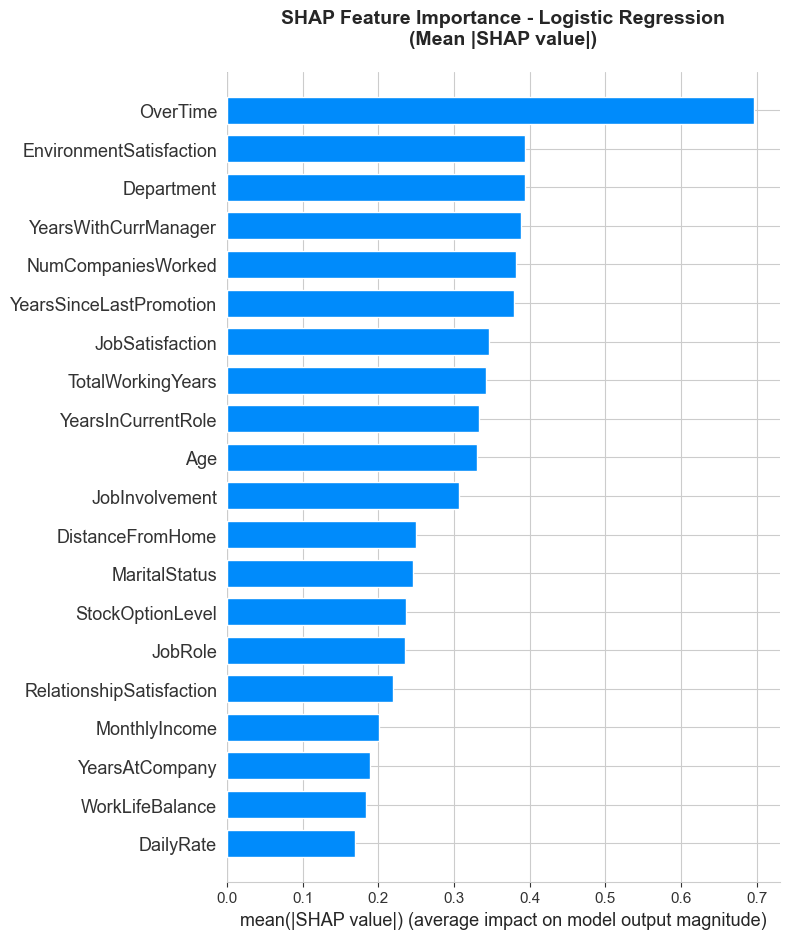

In [127]:
print("Generating Feature Importance Bar Plot - Logistic Regression...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=feature_names_list, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Logistic Regression\n(Mean |SHAP value|)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Generating Waterfall Plots - Logistic Regression...


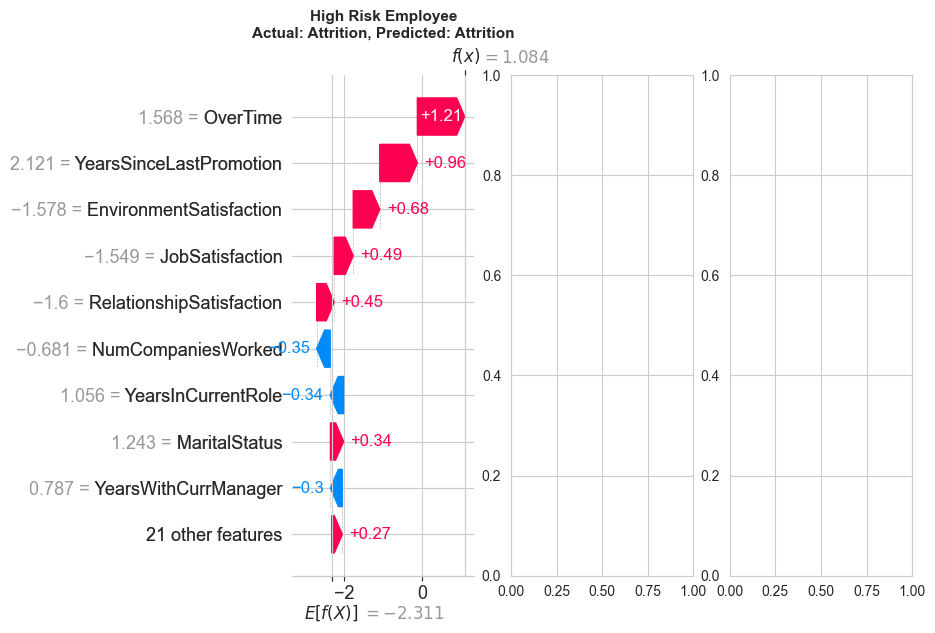

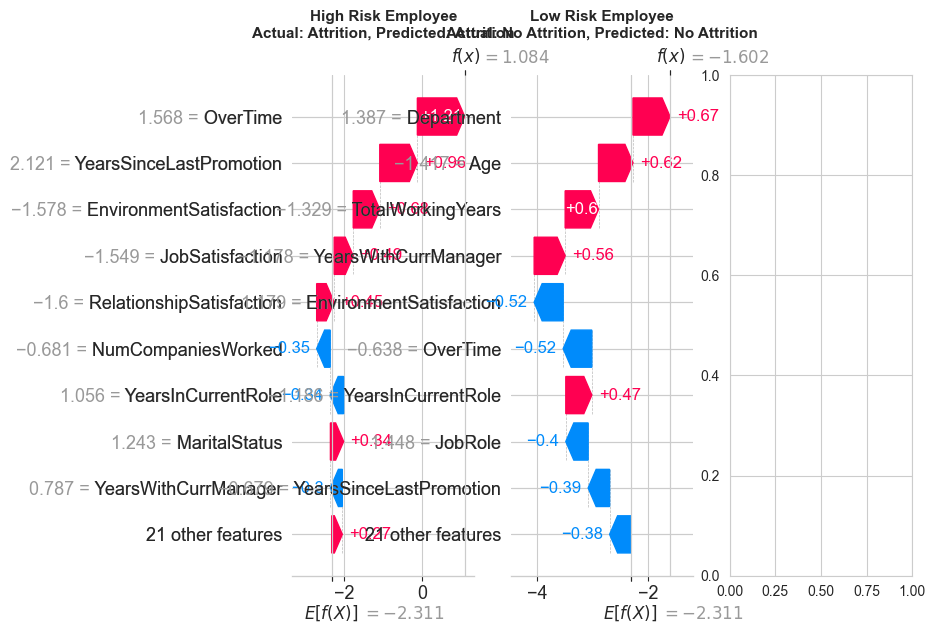

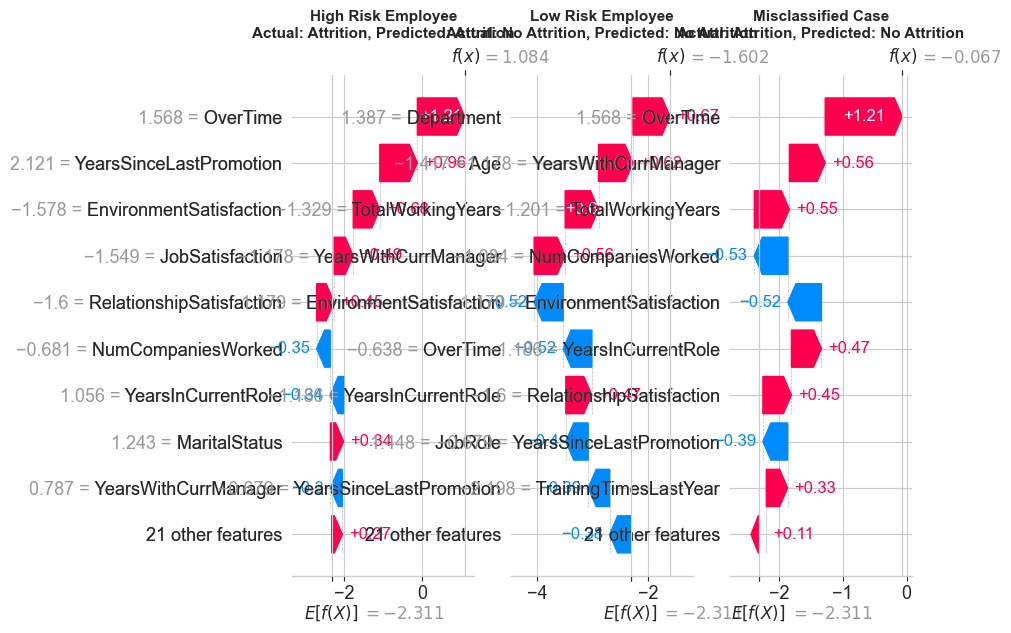

In [134]:
print("Generating Waterfall Plots - Logistic Regression...")

# Select interesting cases
attrition_cases = np.where((y_test.values == 1) & (y_pred_lr == 1))[0]
high_risk_idx = attrition_cases[0] if len(attrition_cases) > 0 else 0

retention_cases = np.where((y_test.values == 0) & (y_pred_lr == 0))[0]
low_risk_idx = retention_cases[0] if len(retention_cases) > 0 else 1

misclassified = np.where(y_test.values != y_pred_lr)[0]
misclass_idx = misclassified[0] if len(misclassified) > 0 else 2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Create shap.Explanation object for waterfall plots
shap_explanation_lr = shap.Explanation(
    values=shap_values_lr,
    base_values=explainer_lr.expected_value,
    data=X_test_scaled,
    feature_names=feature_names_list
)

# Plot 1: High Risk Employee    
plt.sca(axes[0])
shap.waterfall_plot(shap_explanation_lr[high_risk_idx], max_display=10, show=False)
axes[0].set_title(f'High Risk Employee\nActual: Attrition, Predicted: Attrition', 
                  fontsize=11, fontweight='bold')
plt.show()

# Plot 2: Low Risk Employee
plt.sca(axes[1])
shap.waterfall_plot(shap_explanation_lr[low_risk_idx], max_display=10, show=False)
axes[1].set_title(f'Low Risk Employee\nActual: No Attrition, Predicted: No Attrition', 
                  fontsize=11, fontweight='bold')
plt.show()

# Plot 3: Misclassified Case
plt.sca(axes[2])
shap.waterfall_plot(shap_explanation_lr[misclass_idx], max_display=10, show=False)
actual_label = 'Attrition' if y_test.iloc[misclass_idx] == 1 else 'No Attrition'
pred_label = 'Attrition' if y_pred_lr[misclass_idx] == 1 else 'No Attrition'
axes[2].set_title(f'Misclassified Case\nActual: {actual_label}, Predicted: {pred_label}', 
                  fontsize=11, fontweight='bold')
plt.show()

Generating Dependence Plots - Logistic Regression...


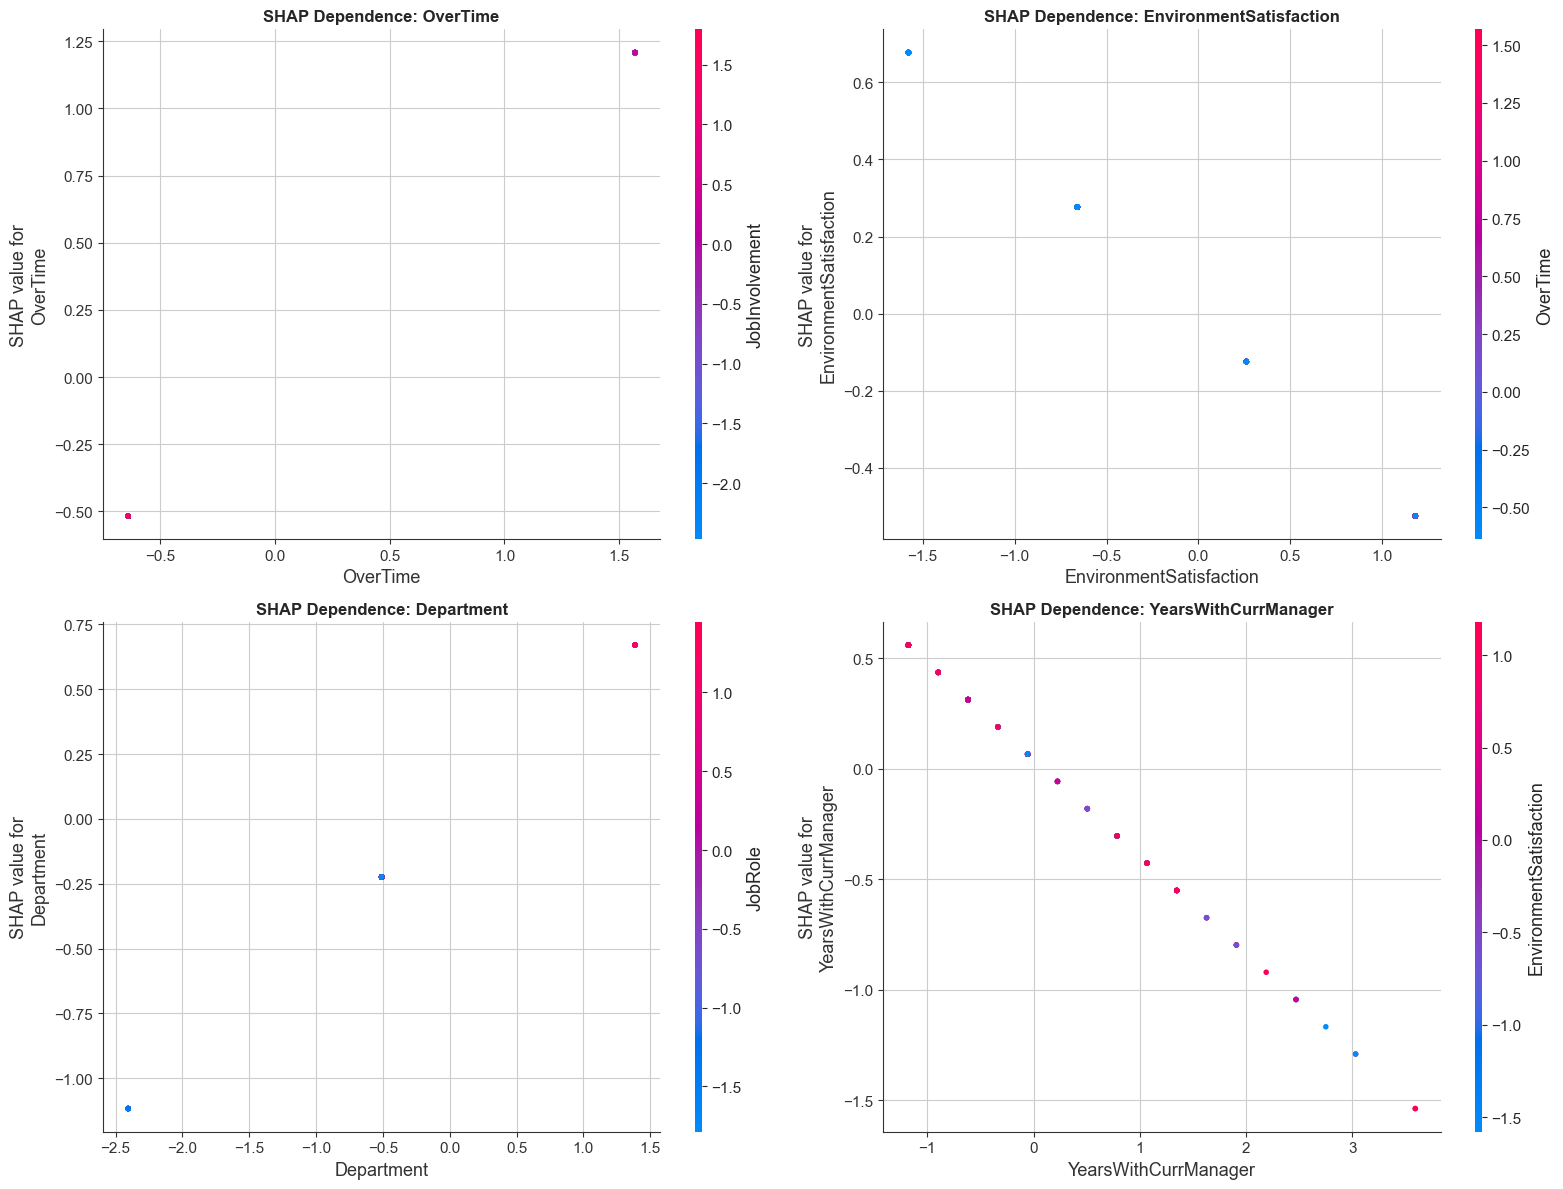

In [132]:
print("Generating Dependence Plots - Logistic Regression...")

top_features = feature_importance_shap_lr.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    feature_idx = feature_names_list.index(feature)
    shap.dependence_plot(
        feature_idx, 
        shap_values_lr, 
        X_test_scaled,
        feature_names=feature_names_list,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [136]:
print("\n" + "=" * 70)
print("SHAP ANALYSIS - DECISION TREE")
print("=" * 70)

# Create SHAP explainer for Decision Tree
print("\nCreating TreeExplainer for Decision Tree...")
explainer_dt = shap.TreeExplainer(dt_model)

# Calculate SHAP values for test set
print("Calculating SHAP values...")
shap_values_dt_raw = explainer_dt.shap_values(X_test_scaled)

# Handle different output formats from TreeExplainer
if isinstance(shap_values_dt_raw, list):
    shap_values_dt = shap_values_dt_raw[1]  # Use class 1 (Attrition)
    expected_value_dt = explainer_dt.expected_value[1] if isinstance(explainer_dt.expected_value, list) else explainer_dt.expected_value
    print("Using SHAP values for class 1 (Attrition)")
elif len(shap_values_dt_raw.shape) == 3:
    shap_values_dt = shap_values_dt_raw[:, :, 1]  # Extract class 1
    expected_value_dt = explainer_dt.expected_value[1] if isinstance(explainer_dt.expected_value, list) else explainer_dt.expected_value
    print("Extracted SHAP values for class 1 from 3D array")
else:
    shap_values_dt = shap_values_dt_raw
    expected_value_dt = explainer_dt.expected_value
    print("Using 2D SHAP values directly")

print(f"SHAP values shape: {shap_values_dt.shape}")

# Global feature importance (mean absolute SHAP values)
feature_importance_shap_dt = pd.DataFrame({
    'Feature': feature_names_list,
    'SHAP_Importance': np.abs(shap_values_dt).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 15 Most Important Features (Decision Tree - SHAP):")
print(feature_importance_shap_dt.head(15).to_string(index=False))


SHAP ANALYSIS - DECISION TREE

Creating TreeExplainer for Decision Tree...
Calculating SHAP values...
Extracted SHAP values for class 1 from 3D array
SHAP values shape: (294, 30)

Top 15 Most Important Features (Decision Tree - SHAP):
                Feature  SHAP_Importance
               OverTime         0.071650
      TotalWorkingYears         0.048140
                    Age         0.034937
          MonthlyIncome         0.027496
          MaritalStatus         0.025042
                JobRole         0.021688
     NumCompaniesWorked         0.020537
EnvironmentSatisfaction         0.019835
             HourlyRate         0.019676
              DailyRate         0.016631
        WorkLifeBalance         0.010841
YearsSinceLastPromotion         0.010450
       DistanceFromHome         0.009156
  TrainingTimesLastYear         0.006681
             Department         0.005054



Generating Summary Plot - Decision Tree...


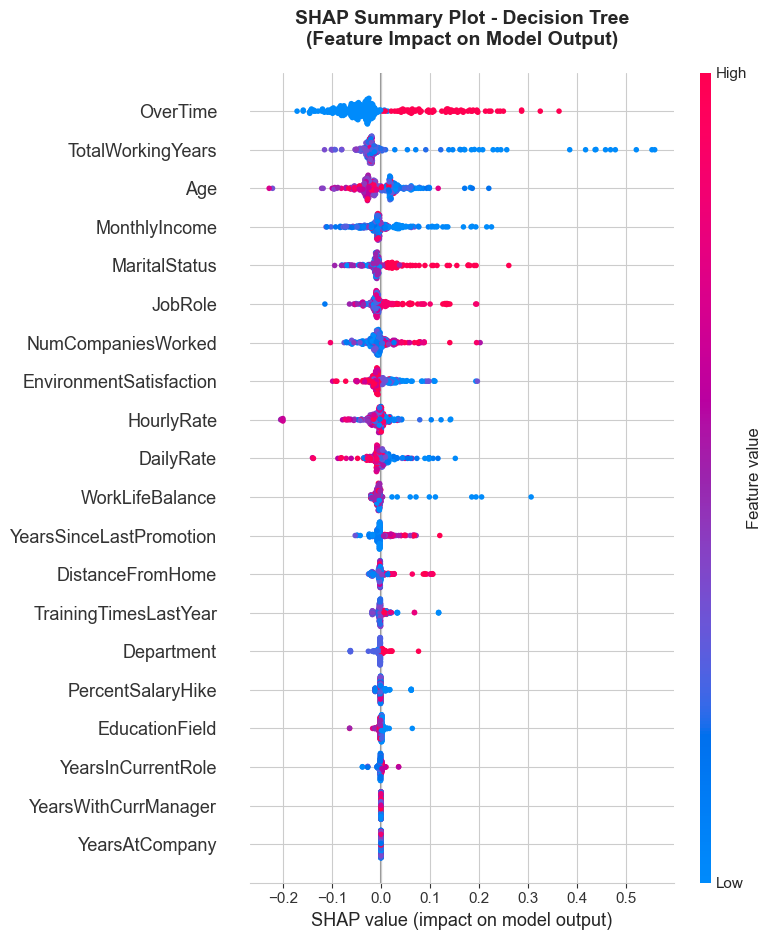

In [137]:
print("\nGenerating Summary Plot - Decision Tree...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_dt, X_test_scaled, feature_names=feature_names_list, show=False)
plt.title('SHAP Summary Plot - Decision Tree\n(Feature Impact on Model Output)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Generating Feature Importance Bar Plot - Decision Tree...


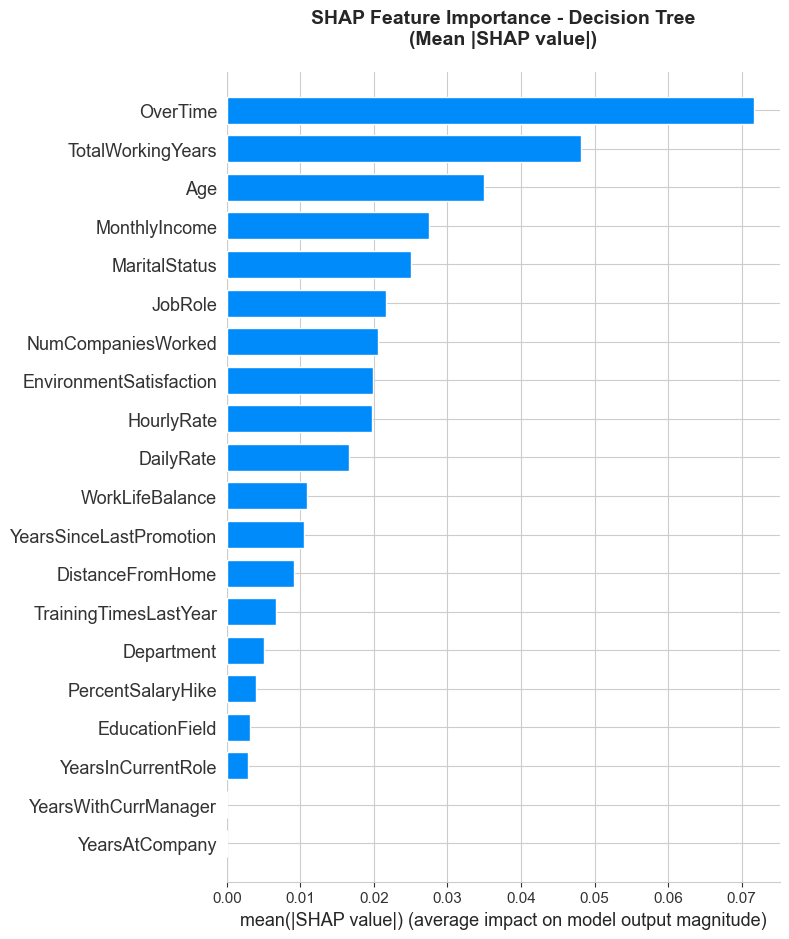

In [138]:
print("Generating Feature Importance Bar Plot - Decision Tree...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_dt, X_test_scaled, feature_names=feature_names_list, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Decision Tree\n(Mean |SHAP value|)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Generating Decision Plot - Decision Tree...


<Figure size 1200x800 with 0 Axes>

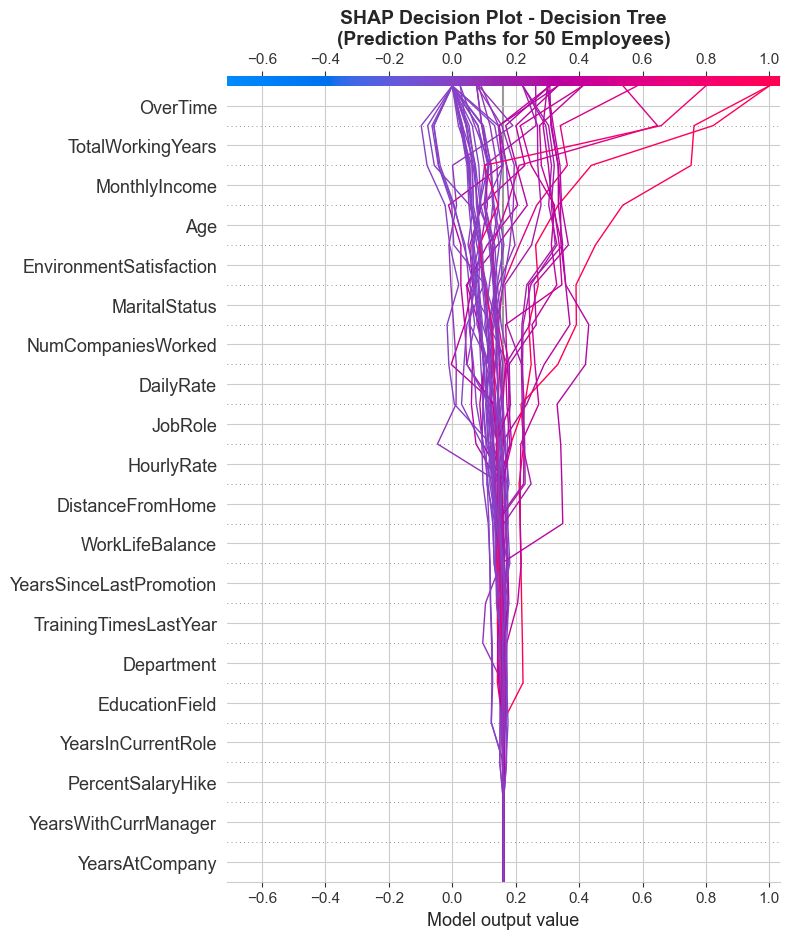

In [140]:
print("Generating Decision Plot - Decision Tree...")

sample_size = min(50, len(X_test_scaled))
sample_indices = np.random.choice(len(X_test_scaled), size=sample_size, replace=False)

plt.figure(figsize=(12, 8))

# For binary classification, use the expected value for class 1 (positive class)
# If expected_value_dt is an array, select the appropriate class
if isinstance(expected_value_dt, np.ndarray):
    base_value = expected_value_dt[1]  # Use index 1 for the positive class
else:
    base_value = expected_value_dt

shap.decision_plot(
    base_value,
    shap_values_dt[sample_indices],
    X_test_scaled[sample_indices],
    feature_names=feature_names_list,
    show=False
)
plt.title('SHAP Decision Plot - Decision Tree\n(Prediction Paths for 50 Employees)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Generating Waterfall Plots - Decision Tree...


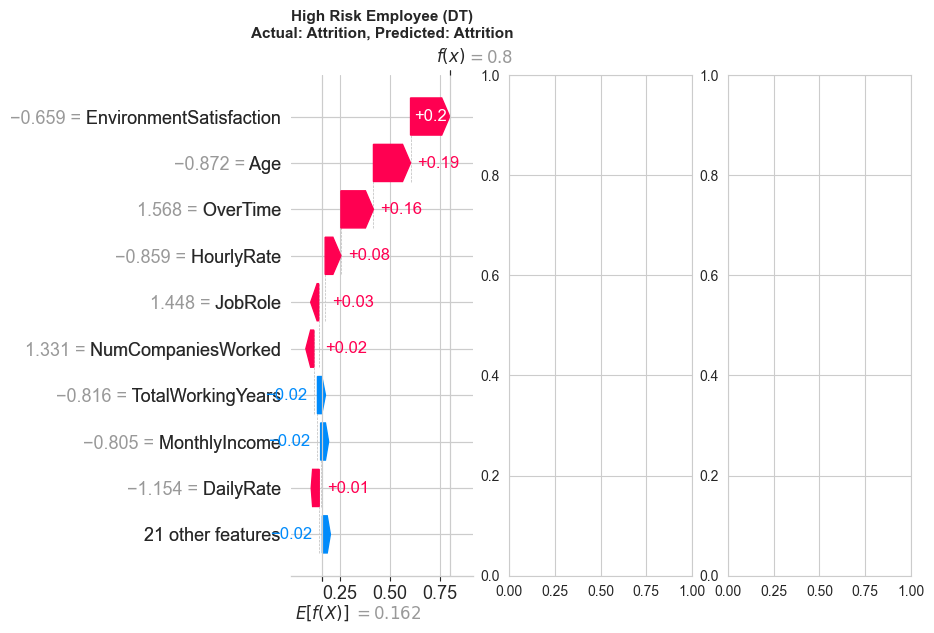

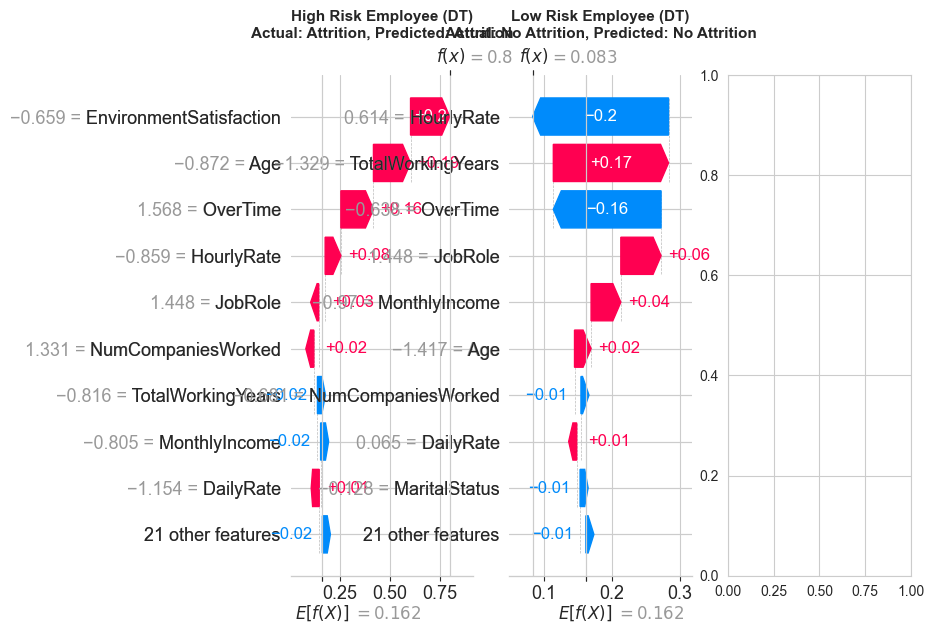

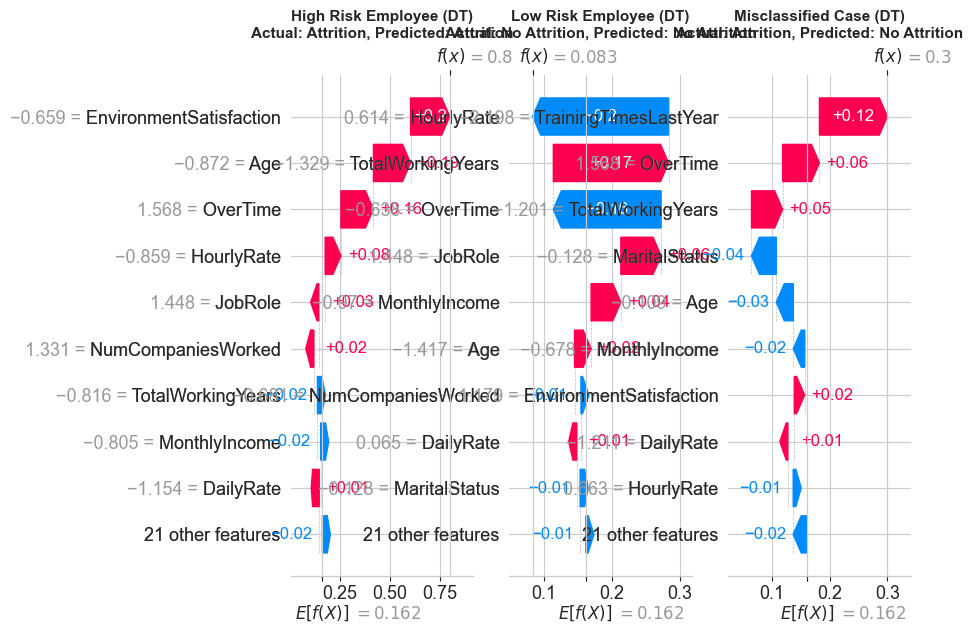

In [144]:
print("Generating Waterfall Plots - Decision Tree...")

attrition_cases_dt = np.where((y_test.values == 1) & (y_pred_dt == 1))[0]
high_risk_idx_dt = attrition_cases_dt[0] if len(attrition_cases_dt) > 0 else 0

retention_cases_dt = np.where((y_test.values == 0) & (y_pred_dt == 0))[0]
low_risk_idx_dt = retention_cases_dt[0] if len(retention_cases_dt) > 0 else 1

misclassified_dt = np.where(y_test.values != y_pred_dt)[0]
misclass_idx_dt = misclassified_dt[0] if len(misclassified_dt) > 0 else 2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# For binary classification, use the expected value for class 1 (positive class)
if isinstance(expected_value_dt, np.ndarray):
    base_value = expected_value_dt[1]  # Use index 1 for the positive class
else:
    base_value = expected_value_dt

# Create shap.Explanation object with scalar base value repeated for all samples
shap_explanation_dt = shap.Explanation(
    values=shap_values_dt,
    base_values=np.full(len(shap_values_dt), base_value),
    data=X_test_scaled,
    feature_names=feature_names_list
)

plt.sca(axes[0])
shap.waterfall_plot(shap_explanation_dt[high_risk_idx_dt], max_display=10, show=False)
axes[0].set_title(f'High Risk Employee (DT)\nActual: Attrition, Predicted: Attrition', 
                  fontsize=11, fontweight='bold')
plt.show()

plt.sca(axes[1])
shap.waterfall_plot(shap_explanation_dt[low_risk_idx_dt], max_display=10, show=False)
axes[1].set_title(f'Low Risk Employee (DT)\nActual: No Attrition, Predicted: No Attrition', 
                  fontsize=11, fontweight='bold')
plt.show()

plt.sca(axes[2])
shap.waterfall_plot(shap_explanation_dt[misclass_idx_dt], max_display=10, show=False)
actual_label_dt = 'Attrition' if y_test.iloc[misclass_idx_dt] == 1 else 'No Attrition'
pred_label_dt = 'Attrition' if y_pred_dt[misclass_idx_dt] == 1 else 'No Attrition'
axes[2].set_title(f'Misclassified Case (DT)\nActual: {actual_label_dt}, Predicted: {pred_label_dt}', 
                  fontsize=11, fontweight='bold')
plt.show()

In [145]:
print("\n" + "=" * 70)
print("COMPARISON: SHAP vs TRADITIONAL FEATURE IMPORTANCE")
print("=" * 70)

# Traditional feature importance
traditional_importance = pd.DataFrame({
    'Feature': feature_names_list,
    'Traditional_Importance': dt_model.feature_importances_
}).sort_values('Traditional_Importance', ascending=False)

# Merge SHAP and traditional importance
comparison_df = feature_importance_shap_dt.merge(
    traditional_importance, on='Feature', how='inner'
)

print("\n📊 Top 15 Features - SHAP vs Traditional Importance:")
print(comparison_df.head(15)[['Feature', 'SHAP_Importance', 'Traditional_Importance']].to_string(index=False))


COMPARISON: SHAP vs TRADITIONAL FEATURE IMPORTANCE

📊 Top 15 Features - SHAP vs Traditional Importance:
                Feature  SHAP_Importance  Traditional_Importance
               OverTime         0.071650                0.104164
      TotalWorkingYears         0.048140                0.219779
                    Age         0.034937                0.122471
          MonthlyIncome         0.027496                0.131958
          MaritalStatus         0.025042                0.056828
                JobRole         0.021688                0.046703
     NumCompaniesWorked         0.020537                0.014588
EnvironmentSatisfaction         0.019835                0.035059
             HourlyRate         0.019676                0.110284
              DailyRate         0.016631                0.078138
        WorkLifeBalance         0.010841                0.019165
YearsSinceLastPromotion         0.010450                0.007664
       DistanceFromHome         0.009156          


Generating Comparison Chart...


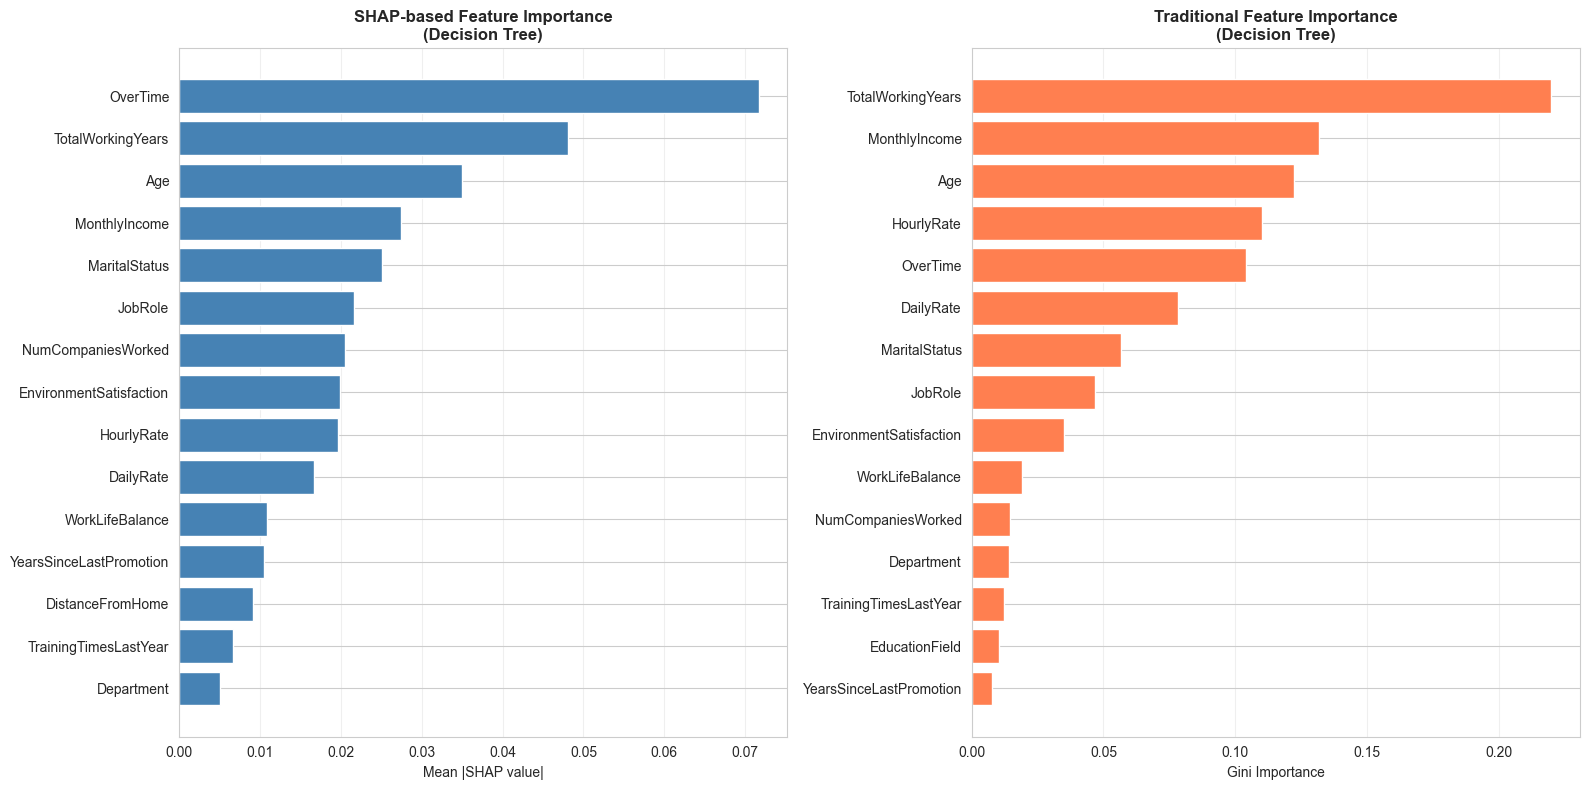

In [146]:
print("\nGenerating Comparison Chart...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SHAP importance
top_15_shap = comparison_df.head(15)
axes[0].barh(range(len(top_15_shap)), top_15_shap['SHAP_Importance'], color='steelblue')
axes[0].set_yticks(range(len(top_15_shap)))
axes[0].set_yticklabels(top_15_shap['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('SHAP-based Feature Importance\n(Decision Tree)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Traditional importance
top_15_trad = traditional_importance.head(15)
axes[1].barh(range(len(top_15_trad)), top_15_trad['Traditional_Importance'], color='coral')
axes[1].set_yticks(range(len(top_15_trad)))
axes[1].set_yticklabels(top_15_trad['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Gini Importance')
axes[1].set_title('Traditional Feature Importance\n(Decision Tree)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
print("\n" + "=" * 70)
print("ACTIONABLE INSIGHTS FROM SHAP ANALYSIS")
print("=" * 70)

# Top features driving attrition
top_5_features = feature_importance_shap_lr.head(5)
print("\nTOP 5 ATTRITION DRIVERS (Logistic Regression):")
for idx, row in top_5_features.iterrows():
    print(f"   {idx+1}. {row['Feature']}: SHAP importance = {row['SHAP_Importance']:.4f}")

top_5_features_dt = feature_importance_shap_dt.head(5)
print("\nTOP 5 ATTRITION DRIVERS (Decision Tree):")
for idx, row in top_5_features_dt.iterrows():
    print(f"   {idx+1}. {row['Feature']}: SHAP importance = {row['SHAP_Importance']:.4f}")

# Identify high-risk employees
print("\nHIGH RISK EMPLOYEE ANALYSIS:")
attrition_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
high_risk_indices = np.argsort(attrition_probs)[-5:][::-1]

print("\nTop 5 Highest Attrition Risk Employees:")
for i, idx in enumerate(high_risk_indices, 1):
    print(f"\n  Employee #{i} (Test Index {idx}):")
    print(f"    - Attrition Probability: {attrition_probs[idx]:.2%}")
    print(f"    - Actual Outcome: {'✗ Left' if y_test.iloc[idx] == 1 else '✓ Stayed'}")
    
    # Top 3 risk factors
    shap_vals = shap_values_lr[idx]
    feature_contributions = pd.DataFrame({
        'Feature': feature_names_list,
        'SHAP_Value': shap_vals
    }).sort_values('SHAP_Value', ascending=False).head(3)
    
    print("    - Top 3 Risk Factors:")
    for _, row in feature_contributions.iterrows():
        print(f"      • {row['Feature']}: {row['SHAP_Value']:.4f}")


ACTIONABLE INSIGHTS FROM SHAP ANALYSIS

TOP 5 ATTRITION DRIVERS (Logistic Regression):
   19. OverTime: SHAP importance = 0.6958
   8. EnvironmentSatisfaction: SHAP importance = 0.3943
   4. Department: SHAP importance = 0.3936
   30. YearsWithCurrManager: SHAP importance = 0.3889
   18. NumCompaniesWorked: SHAP importance = 0.3815

TOP 5 ATTRITION DRIVERS (Decision Tree):
   19. OverTime: SHAP importance = 0.0717
   24. TotalWorkingYears: SHAP importance = 0.0481
   1. Age: SHAP importance = 0.0349
   16. MonthlyIncome: SHAP importance = 0.0275
   15. MaritalStatus: SHAP importance = 0.0250

HIGH RISK EMPLOYEE ANALYSIS:

Top 5 Highest Attrition Risk Employees:

  Employee #1 (Test Index 200):
    - Attrition Probability: 89.13%
    - Actual Outcome: ✗ Left
    - Top 3 Risk Factors:
      • OverTime: 1.2074
      • Age: 0.8460
      • Department: 0.6702

  Employee #2 (Test Index 92):
    - Attrition Probability: 87.48%
    - Actual Outcome: ✗ Left
    - Top 3 Risk Factors:
      • Ov

In [148]:
print("\n" + "=" * 70)
print("✅ SHAP ANALYSIS COMPLETE!")
print("=" * 70)

print("""
📋 ANALYSIS SUMMARY:

✓ SHAP values calculated for both Logistic Regression and Decision Tree
✓ Generated 9 comprehensive visualizations:
  - Summary plots (feature importance with directional impact)
  - Bar plots (global feature importance rankings)
  - Waterfall plots (individual prediction explanations)
  - Dependence plots (feature interactions)
  - Decision plots (prediction paths)
  - Comparison charts (SHAP vs traditional importance)

✓ Identified top attrition drivers for both models
✓ Analyzed high-risk employees with specific risk factors
✓ Provided actionable insights for HR interventions

🎯 KEY BENEFITS OF SHAP:
- Transparent, theoretically-sound explanations
- Shows both magnitude AND direction of feature impact
- Reveals feature interactions
- Explains individual predictions
- Builds trust in model predictions
- Guides data-driven HR decisions

💡 NEXT STEPS:
- Review top risk factors and design intervention strategies
- Analyze high-risk employees for targeted retention efforts
- Use individual SHAP explanations in stakeholder discussions
- Monitor feature importance over time as you retrain models
""")

print("=" * 70)


✅ SHAP ANALYSIS COMPLETE!

📋 ANALYSIS SUMMARY:

✓ SHAP values calculated for both Logistic Regression and Decision Tree
✓ Generated 9 comprehensive visualizations:
  - Summary plots (feature importance with directional impact)
  - Bar plots (global feature importance rankings)
  - Waterfall plots (individual prediction explanations)
  - Dependence plots (feature interactions)
  - Decision plots (prediction paths)
  - Comparison charts (SHAP vs traditional importance)

✓ Identified top attrition drivers for both models
✓ Analyzed high-risk employees with specific risk factors
✓ Provided actionable insights for HR interventions

🎯 KEY BENEFITS OF SHAP:
- Transparent, theoretically-sound explanations
- Shows both magnitude AND direction of feature impact
- Reveals feature interactions
- Explains individual predictions
- Builds trust in model predictions
- Guides data-driven HR decisions

💡 NEXT STEPS:
- Review top risk factors and design intervention strategies
- Analyze high-risk employ

In [151]:
df.to_excel("employee_attrition.xlsx", index=False)